## # Tridiagonal Linear Systems in Python

This notebook implements the Thomas algorithm for solving tridiagonal
linear systems and compares its runtime with dense and sparse solvers
from SciPy.

## Objectives
- implement the Thomas algorithm
- validate correctness against a reference solver
- compare runtimes for increasing system sizes
- discuss the benefit of exploiting matrix structure

Correctness test
System size n           : 100
max |x_thomas - x_ref|  : 0.000e+00
Residual ||Ax - b||     : 3.140e-16

Finished benchmark for n = 10
Finished benchmark for n = 100
Finished benchmark for n = 500
Finished benchmark for n = 1000
Finished benchmark for n = 2000


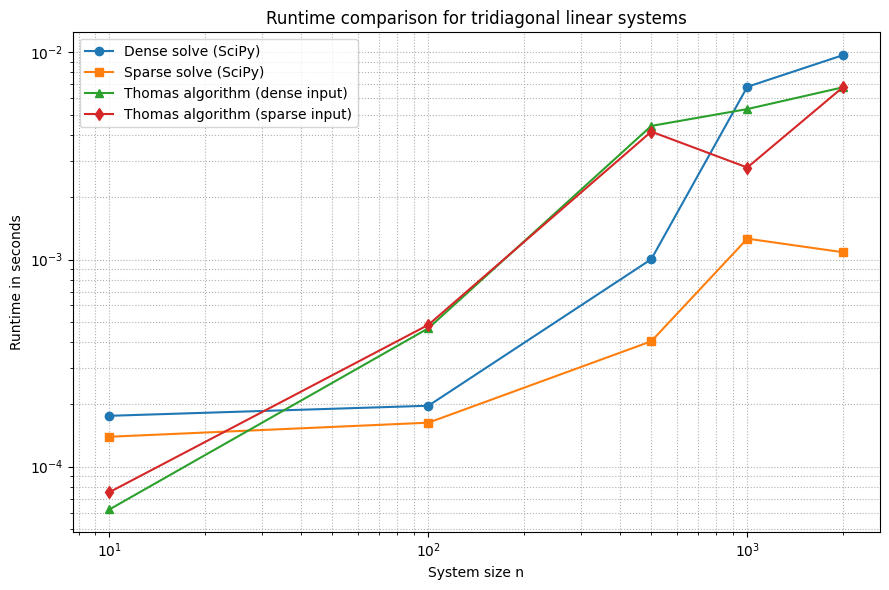

Plot saved to: tridiagonal_runtime_comparison.png


In [1]:
# ================================================
# Tridiagonal Linear Systems in Python
# Thomas Algorithm, Validation, and Runtime Benchmark
# ================================================

import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.linalg import solve as dense_solve
from scipy.sparse.linalg import spsolve


# ------------------------------------------------
# System generation
# ------------------------------------------------
def setup_tridiagonal_system(n: int):
    """
    Create the tridiagonal linear system Ax = b with

        2 on the main diagonal
        1 on the first lower and upper diagonals
        b = [2, 2, ..., 2]^T
    """
    if n < 2:
        raise ValueError("n must be at least 2.")

    main = np.full(n, 2.0)
    off = np.ones(n - 1)

    A_dense = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

    A_sparse = sparse.diags(
        diagonals=[off, main, off],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="csr"
    )

    b = np.full(n, 2.0)

    return A_dense, A_sparse, b


# ------------------------------------------------
# Tridiagonal extraction
# ------------------------------------------------
def extract_tridiagonals(A):
    """
    Extract the three diagonals of a tridiagonal matrix.
    """
    if sparse.isspmatrix(A):
        diag = A.diagonal().astype(float)
        lower = A.diagonal(-1).astype(float)
        upper = A.diagonal(1).astype(float)
    else:
        diag = np.diag(A).astype(float)
        lower = np.diag(A, k=-1).astype(float)
        upper = np.diag(A, k=1).astype(float)

    return lower, diag, upper


# ------------------------------------------------
# Thomas algorithm
# ------------------------------------------------
def thomas_solve(A, b):
    """
    Solve a tridiagonal linear system Ax = b using the Thomas algorithm.
    """
    b = np.asarray(b, dtype=float)
    lower, diag, upper = extract_tridiagonals(A)

    n = len(diag)
    if len(b) != n:
        raise ValueError("Dimension mismatch between A and b.")

    c = upper.copy()
    d = diag.copy()
    rhs = b.copy()

    # Forward elimination
    for i in range(1, n):
        if abs(d[i - 1]) < 1e-15:
            raise ZeroDivisionError("Zero pivot encountered in Thomas algorithm.")
        factor = lower[i - 1] / d[i - 1]
        d[i] = d[i] - factor * c[i - 1]
        rhs[i] = rhs[i] - factor * rhs[i - 1]

    # Back substitution
    x = np.zeros(n, dtype=float)

    if abs(d[-1]) < 1e-15:
        raise ZeroDivisionError("Zero pivot encountered in Thomas algorithm.")
    x[-1] = rhs[-1] / d[-1]

    for i in range(n - 2, -1, -1):
        if abs(d[i]) < 1e-15:
            raise ZeroDivisionError("Zero pivot encountered in Thomas algorithm.")
        x[i] = (rhs[i] - c[i] * x[i + 1]) / d[i]

    return x


# ------------------------------------------------
# Benchmark helper
# ------------------------------------------------
def benchmark(function, *args, repeats=5, **kwargs):
    """
    Measure execution time of a function and return the median runtime.
    """
    times = []
    result = None

    for _ in range(repeats):
        start = time.perf_counter()
        result = function(*args, **kwargs)
        end = time.perf_counter()
        times.append(end - start)

    return result, float(np.median(times))


# ------------------------------------------------
# Correctness test
# ------------------------------------------------
def correctness_test(n=100):
    """
    Validate the Thomas algorithm against a dense reference solver.
    """
    A_dense, _, b = setup_tridiagonal_system(n)

    x_thomas = thomas_solve(A_dense, b)
    x_reference = dense_solve(A_dense, b)

    max_error = np.max(np.abs(x_thomas - x_reference))
    residual = np.linalg.norm(A_dense @ x_thomas - b)

    print("Correctness test")
    print(f"System size n           : {n}")
    print(f"max |x_thomas - x_ref|  : {max_error:.3e}")
    print(f"Residual ||Ax - b||     : {residual:.3e}")
    print()

    return max_error, residual


# ------------------------------------------------
# Compare solver runtimes
# ------------------------------------------------
def compare_solver_runtimes(sizes, repeats=5):
    """
    Compare runtime of different solvers for multiple system sizes.
    """
    results = {
        "sizes": [],
        "dense_solve": [],
        "sparse_solve": [],
        "thomas_dense": [],
        "thomas_sparse": [],
    }

    for n in sizes:
        A_dense, A_sparse, b = setup_tridiagonal_system(n)

        _, t_dense = benchmark(dense_solve, A_dense, b, repeats=repeats)
        _, t_sparse = benchmark(spsolve, A_sparse, b, repeats=repeats)
        _, t_thomas_dense = benchmark(thomas_solve, A_dense, b, repeats=repeats)
        _, t_thomas_sparse = benchmark(thomas_solve, A_sparse, b, repeats=repeats)

        results["sizes"].append(n)
        results["dense_solve"].append(t_dense)
        results["sparse_solve"].append(t_sparse)
        results["thomas_dense"].append(t_thomas_dense)
        results["thomas_sparse"].append(t_thomas_sparse)

        print(f"Finished benchmark for n = {n}")

    return results


# ------------------------------------------------
# Plot runtime comparison
# ------------------------------------------------
def plot_runtime_comparison(results):
    """
    Create a log-log runtime plot from benchmark results.
    """
    sizes = results["sizes"]

    plt.figure(figsize=(9, 6))
    plt.loglog(sizes, results["dense_solve"], "o-", label="Dense solve (SciPy)")
    plt.loglog(sizes, results["sparse_solve"], "s-", label="Sparse solve (SciPy)")
    plt.loglog(sizes, results["thomas_dense"], "^-", label="Thomas algorithm (dense input)")
    plt.loglog(sizes, results["thomas_sparse"], "d-", label="Thomas algorithm (sparse input)")

    plt.xlabel("System size n")
    plt.ylabel("Runtime in seconds")
    plt.title("Runtime comparison for tridiagonal linear systems")
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# Save plot
# ------------------------------------------------
def save_runtime_plot(results, filename="tridiagonal_runtime_comparison.png"):
    """
    Save the runtime comparison plot to an image file.
    """
    sizes = results["sizes"]

    plt.figure(figsize=(9, 6))
    plt.loglog(sizes, results["dense_solve"], "o-", label="Dense solve (SciPy)")
    plt.loglog(sizes, results["sparse_solve"], "s-", label="Sparse solve (SciPy)")
    plt.loglog(sizes, results["thomas_dense"], "^-", label="Thomas algorithm (dense input)")
    plt.loglog(sizes, results["thomas_sparse"], "d-", label="Thomas algorithm (sparse input)")

    plt.xlabel("System size n")
    plt.ylabel("Runtime in seconds")
    plt.title("Runtime comparison for tridiagonal linear systems")
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Plot saved to: {filename}")


# ------------------------------------------------
# Example execution in notebook
# ------------------------------------------------

# 1) Validate correctness
correctness_test(n=100)

# 2) Benchmark selected system sizes
# Etwas moderat gewählt, damit es in Colab sauber läuft
sizes = [10, 100, 500, 1000, 2000]
results = compare_solver_runtimes(sizes=sizes, repeats=3)

# 3) Show plot
plot_runtime_comparison(results)

# 4) Save plot as PNG for later download
save_runtime_plot(results, filename="tridiagonal_runtime_comparison.png")

## Conclusion

The benchmark shows that the Thomas algorithm is highly efficient for
tridiagonal systems because it exploits the matrix structure directly.
Dense solvers become more expensive as the system size increases,
while sparse solvers remain much more competitive.
This illustrates the importance of choosing algorithms that match
the structure of the problem.